# I. Nhập và xử lí dữ liệu

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 3.7 MB/s eta 0:00:00


In [3]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import category_encoders as ce

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.cluster import KMeans

In [4]:
!pip install category-encoders

## a. Nhập dữ liệu

In [5]:
!git clone https://github.com/22521518/data-colab.git
%cd data-colab/retail-data

file_name = "retail_data.csv"

Cloning into 'data-colab'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 25 (delta 4), reused 18 (delta 2), pack-reused 5 (from 1)
Receiving objects: 100% (25/25), 75.57 MiB | 9.52 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (8/8), done.
/content/data-colab/retail-data


In [6]:
df = pd.read_csv(file_name)
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


## b. Tiền xử lý dữ liệu


In [7]:
def check_df_info(data_frame):
  df_info = pd.concat([data_frame.dtypes, data_frame.isna().sum()], axis=1)
  df_info.columns = ['Data Type', 'Missing Values']
  df_info['Total Rows'] = data_frame.shape[0]
  df_info['Non-Null Count'] = data_frame.notna().sum()
  return df_info

### i. Xử lý giá trị khuyết

**Phương pháp xử lí dữ liệu**

|STT| Tên cột | Số lượng giá trị khuyết | Phương pháp điền khuyết áp dụng |
|---|---|---|---|
| 1 | Transaction_ID | 333 | loại bỏ giá trị khuyết |
| 2 | Customer_ID | 308 | loại bỏ giá trị khuyết |
| 3 | Name | 382 | loại bỏ giá trị khuyết |
| 4 | Email | 347 | loại bỏ giá trị khuyết |
| 5 | Phone | 362 | loại bỏ giá trị khuyết |
| 6 | Address | 315 | loại bỏ giá trị khuyết |
| 7 | City | 248 | loại bỏ giá trị khuyết |
| 8| State | 281 | loại bỏ giá trị khuyết |
| 9 | Zipcode | 340 | loại bỏ giá trị khuyết |
| 10 | Country | 271 | loại bỏ giá trị khuyết |
| 11 | Age | 173 | mean (trung bình) |
| 12 | Gender| 317 | mode (xuất hiện nhiều nhất) |
| 13 | Income | 290 | ffill (giá trị dòng trên) |
| 14 | Customer_Segment | 215 | mode (xuất hiện nhiều nhất) |
| 15 | Date | 359 | loại bỏ giá trị khuyết |
| 16 | Year | 350 | lấy 'year' ở cột Date |
| 17 | Month | 273 | lấy 'month' ở cột Date |
| 18 | Time | 350 | mode (xuất hiện nhiều nhất) |
| 19 | Total_Purchases | 361 | mean (trung bình) |
| 20 | Amount | 357 | mean (trung bình) |
| 21 | Total_Amount | 350 | mean (trung bình) |
| 22 | Product_Category | 283 | loại bỏ giá trị khuyết |
| 23 | Product_Brand | 281 | điền giá trị 'Unknown' |
| 24 | Product_Type | 0 |
| 25 | Feedback | 184 | mode (xuất hiện nhiều nhất) |
| 26 | Shipping_Method | 337 | mode (xuất hiện nhiều nhất) |
| 27 | Payment_Method | 297 | mode (xuất hiện nhiều nhất) |
| 28 | Order_Status | 235 | mode (xuất hiện nhiều nhất) |
| 29 | Ratings | 184 | median (trung vị) |
| 30 | products | 0 |

In [8]:
header_replace_by_drop_value = ['Transaction_ID', 'Customer_ID', 'Name',
                                'Email', 'Phone', 'Address', 'City', 'State',
                                'Zipcode', 'Country', 'Date', 'Product_Category'] # loại bỏ giá trị khuyết
header_replace_by_mean_value = ['Age', 'Amount', 'Total_Amount', 'Total_Purchases'] # mean (trung bình) , 'Income'
header_replace_by_mode_value = ['Gender', 'Customer_Segment', 'Time', 'Feedback',
                                'Shipping_Method', 'Payment_Method', 'Order_Status'] # mode (xuất hiện nhiều nhất)
header_replace_by_unknown_value = ['Product_Brand',] # điền giá trị 'Unknown'
header_replace_by_median_value = ['Ratings'] # median (trung vị)
header_relace_by_forward_value = ['Income'] #	ffill (giá trị dòng trên)

**Định nghĩa hàm thay thế**

In [9]:
def replace_cols_with_drop_value(data_frame, header_names): # loại bỏ giá trị khuyết
    for col in header_names:
      if col in data_frame.columns:
        data_frame = data_frame.dropna(subset=[col])
    return data_frame

def replace_cols_with_mean_value(data_frame, header_names): # mean (trung bình) , 'Income'
    for col in header_names:
      if col in data_frame.columns:
        data_frame[col] = data_frame[col].fillna(data_frame[col].mean())
    return data_frame

def replace_cols_with_mode_value(data_frame, header_names): # mode (xuất hiện nhiều nhất)
    for col in header_names:
      if col in data_frame.columns:
        data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])
    return data_frame

def replace_cols_with_unknown_value(data_frame, header_names): # điền giá trị 'Unknown'
    for col in header_names:
      if col in data_frame.columns:
        data_frame[col] = data_frame[col].fillna('Unknown')
    return data_frame

def replace_cols_with_median_value(data_frame, header_names): # median (trung vị)
    for col in header_names:
      if col in data_frame.columns:
        data_frame[col] = data_frame[col].fillna(data_frame[col].median())
    return data_frame

def replace_cols_with_forward_value(data_frame, header_names): #	ffill (giá trị dòng trên)
    for col in header_names:
      if col in data_frame.columns:
        data_frame[col] = data_frame[col].ffill()
    return data_frame


In [10]:
df = replace_cols_with_drop_value(df, header_replace_by_drop_value) # loại bỏ giá trị khuyết
df = replace_cols_with_mean_value(df, header_replace_by_mean_value) # mean (trung bình) , 'Income'
df = replace_cols_with_mode_value(df, header_replace_by_mode_value)  # mode (xuất hiện nhiều nhất)
df = replace_cols_with_unknown_value(df, header_replace_by_unknown_value) # điền giá trị 'Unknown'
df = replace_cols_with_median_value(df, header_replace_by_median_value) # median (trung vị)
df = replace_cols_with_forward_value(df, header_relace_by_forward_value) #	ffill (giá trị dòng trên)

df.isnull().sum().sum(), df.isna().sum().sum() # Month, Year value

(616, 616)

### ii. Thay thế cột 'Month' và 'Year' theo 'Date'

Chuẩn hóa dữ liệu cột 'Date'bởi vì định dạng không đồng nhất (11-01-23, 1/22/2024, 01-10-24)

In [11]:
def standardize_date_column(date_frame):
  date_series = date_frame['Date']
  format = '%m-%d-%y'
  dates_with_dash = pd.to_datetime(date_series, format='%m-%d-%y', errors='coerce') # Format dữ liệu theo kiểu '%m-%d-%y', điều này sẽ biến những cột không có dạng này thành NaT (rỗng)
  dates_with_slash = pd.to_datetime(date_series, format='%m/%d/%Y', errors='coerce') # Format dữ liệu theo kiểu '%m/%d/%Y', điều này sẽ biến những cột không có dạng này thành NaT (rỗng)
   # Vì trong bộ dữ liệu chỉ có 2 dạng format trên, nên ta sẽ đồng bộ cột "Date" theo dạng '%m-%d-%y'
  dates_with_dash = dates_with_dash.fillna(dates_with_slash) # Vì chỉ có 2 dạng, nên những giá trị NaT sẽ được fill với giá trị '%m/%d/%Y'
  date_frame['Date'] = dates_with_dash
  date_frame['Date'] = pd.to_datetime(date_frame['Date'], format=format) # Format kiểu dữ liệu của cột
  return date_frame

In [12]:
df = standardize_date_column(df)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time # đổi định dạng hour/minute/seconds

In [13]:
df['Date'].unique()

<DatetimeArray>
['2023-09-18 00:00:00', '2023-12-31 00:00:00', '2023-04-26 00:00:00',
 '2023-05-08 00:00:00', '2024-01-10 00:00:00', '2023-09-21 00:00:00',
 '2023-06-26 00:00:00', '2023-03-24 00:00:00', '2024-01-06 00:00:00',
 '2023-10-04 00:00:00',
 ...
 '2024-01-23 00:00:00', '2023-07-24 00:00:00', '2023-07-07 00:00:00',
 '2023-10-23 00:00:00', '2023-03-09 00:00:00', '2023-11-10 00:00:00',
 '2023-08-21 00:00:00', '2023-03-31 00:00:00', '2023-08-23 00:00:00',
 '2024-01-24 00:00:00']
Length: 366, dtype: datetime64[ns]

### iii. Kiểm tra kiểu dữ liệu

|STT| Tên cột | Pandas | Thực tế | Kết quả |
|---|---|---|---|---|
| 1 | Transaction_ID | float64 | float64 | true |
| 2 | Customer_ID | float64 | float64 | true |
| 3 | Name | object | object | true |
| 4 | Email | object | object | true |
| 5 | Phone | float64 | float64 | true |
| 6 | Address | object | object | true |
| 7 | City | object | object | true |
| 8| State | object | object | true |
| 9 | Zipcode | float64 | float64 | true |
| 10 | Country | object | object | true |
| 11 | Age | float64 | int64 | false |
| 12 | Gender | object | object | true |
| 13 | Income | object | object | true |
| 14 | Customer_Segment | object | object | true |
| 15 | Date | datetime64[ns]	 | datetime64[ns] | true |
| 16 | Year | int32 | int32 | true |
| 17 | Month | int32 | int32 | true |
| 18 | Time | object | object | true |
| 19 | Total_Purchases | float64 | int32 | false |
| 20 | Amount | float64 | float64 | true | 357 |
| 21 | Total_Amount | float64 | float64 | true |
| 22| Product_Category | object | object | true |
| 23 | Product_Brand | object | object | true |
| 24 | Product_Type | object | object | true |
| 25 | Feedback | object | object | true |
| 26 | Shipping_Method | object | object | true |
| 27 | Payment_Method | object | object | true |
| 28 | Order_Status | object | object | true |
| 29 | Ratings | float64 | int64 | false |
| 30 | products | object | object | true |

In [14]:
def change_data_type(data_frame):
  header_type_dict = {
    'Age': 'int32',
    'Total_Purchases': 'int64',
    'Ratings': 'int64',
  }
  for col, dtype in header_type_dict.items():
    if col in data_frame.columns:
      data_frame[col] = data_frame[col].astype(dtype)

  return data_frame

In [15]:
df = change_data_type(df) # Đổi kiểu dữ liệu đúng theo bảng
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298208 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    298208 non-null  float64       
 1   Customer_ID       298208 non-null  float64       
 2   Name              298208 non-null  object        
 3   Email             298208 non-null  object        
 4   Phone             298208 non-null  float64       
 5   Address           298208 non-null  object        
 6   City              298208 non-null  object        
 7   State             298208 non-null  object        
 8   Zipcode           298208 non-null  float64       
 9   Country           298208 non-null  object        
 10  Age               298208 non-null  int32         
 11  Gender            298208 non-null  object        
 12  Income            298208 non-null  object        
 13  Customer_Segment  298208 non-null  object        
 14  Date     

### iv. Xử lý dữ liệu bất thường

**Dữ liệu có điểm bất thường:**
Mã khách hàng trùng nhưng thông tin cá nhân không khớp nhau

In [16]:
df[df['Customer_ID'].duplicated(keep=False)].sort_values(by='Customer_ID').head().T # Chuyển vị ma trận (cột => hàng)

,297459,290160,145221,231852,9772
Transaction_ID,8901617.0,4759669.0,4340470.0,8180050.0,6592641.0
Customer_ID,10000.0,10000.0,10000.0,10000.0,10001.0
Name,Teresa Cole,Robert Cook,Thomas Thompson,John Patterson,Miss Kristen Ingram
Email,Molly61@gmail.com,Caroline60@gmail.com,Christy6@gmail.com,Victoria5@gmail.com,Robert93@gmail.com
Phone,3057277425.0,8428883216.0,6640432656.0,6855934982.0,5583788499.0
Address,14721 Robert Glen Apt. 663,232 Lawrence Greens,719 Kevin Route,136 Perkins Street,825 Kristen Cape
City,Hamburg,San Antonio,San Francisco,Phoenix,Portsmouth
State,Berlin,Nevada,Maine,North Carolina,England
Zipcode,56734.0,89220.0,87288.0,28468.0,88498.0
Country,Germany,USA,USA,USA,UK


In [17]:
cus_duplicates = df['Customer_ID'].duplicated().sum()
print(f"Số lượng mã khách hàng trùng: {cus_duplicates}")

Số lượng mã khách hàng trùng: 211575


**Tạo mã khách hàng mới: dựa trên tên, giới tính, địa chỉ nhà và năm sinh**

In [18]:
df['Birth'] = df['Year'] - df['Age']
df['Birth'] = df['Birth'].astype('str')

# Tạo một cột mới với một dãy giá trị gộp sau: Tên + Giới tính + Năm Sinh + Đia chỉ
df['unique_customer_key'] = df[['Name', 'Country', 'Gender', 'Birth', 'City', 'State', 'Address']].agg('-'.join, axis=1)

# Tạo mã khách hàng mới dựa trên dãy giá trị vừa tạo
df['new_customer_id'] = pd.factorize(df['unique_customer_key'])[0]

df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products,Birth,unique_customer_key,new_customer_id
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,Shorts,Excellent,Same-Day,Debit Card,Shipped,5,Cycling shorts,2002,Michelle Harrington-Germany-Male-2002-Dortmund...,0
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,Tablet,Excellent,Standard,Credit Card,Processing,4,Lenovo Tab,2004,Kelsey Hill-UK-Female-2004-Nottingham-England-...,1
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,Children's,Average,Same-Day,Credit Card,Processing,2,Sports equipment,1975,Scott Jensen-Australia-Male-1975-Geelong-New S...,2
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,Tools,Excellent,Standard,PayPal,Processing,4,Utility knife,1967,Joseph Miller-Canada-Male-1967-Edmonton-Ontari...,3
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,Chocolate,Bad,Standard,Cash,Shipped,1,Chocolate cookies,2002,Debra Coleman-UK-Male-2002-Bristol-England-581...,4


In [19]:
num_duplicates = df['new_customer_id'].duplicated().sum()
print(f"Số lượng mã khách hàng trùng: {num_duplicates}")

Số lượng mã khách hàng trùng: 1052


In [20]:
df[df['new_customer_id'].duplicated(keep=False)].sort_values(by='new_customer_id').head(3)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products,Birth,unique_customer_key,new_customer_id
32415,9773603.0,55997.0,Jennifer Garcia,Lisa48@gmail.com,9.432967e+09,8965 Chen Canyon,Ballarat,New South Wales,60083.0,Australia,...,Chocolate,Good,Express,PayPal,Delivered,3,Dark chocolate,2001,Jennifer Garcia-Australia-Female-2001-Ballarat...,32101
301659,9773603.0,55997.0,Jennifer Garcia,Lisa48@gmail.com,9.432967e+09,8965 Chen Canyon,Ballarat,New South Wales,60083.0,Australia,...,Chocolate,Good,Express,Cash,Shipped,3,Chocolate bars,2001,Jennifer Garcia-Australia-Female-2001-Ballarat...,32101
301217,3643440.0,24820.0,Nathan Salazar,Richard47@gmail.com,3.988943e+09,66144 Contreras Ridges,Edinburgh,England,87225.0,UK,...,Chocolate,Bad,Same-Day,Cash,Pending,1,Dark chocolate,2001,Nathan Salazar-UK-Male-2001-Edinburgh-England-...,41678


**Số lượng mã khách hàng trùng giảm (còn 1052) do giao dịch nhiều lần, nhưng có một số khách hàng có thông tin không đồng nhất về Income => cho thấy thu nhập người dùng không ổn định**

### v. Kiểm tra mã giao dịch trùng

In [21]:
trans_duplicates = df['Transaction_ID'].duplicated().sum()
print(f"Số lượng mã giao dịch trùng: {trans_duplicates}")

Số lượng mã giao dịch trùng: 7079


In [22]:
df[df['Transaction_ID'].duplicated(keep=False)].sort_values(by='Transaction_ID').head(3)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products,Birth,unique_customer_key,new_customer_id
91025,1003092.0,27378.0,Nicholas Moore,Danielle79@gmail.com,6.988331e+09,5564 Daniel Garden Apt. 073,Chicago,Connecticut,6790.0,USA,...,Water,Good,Standard,PayPal,Delivered,4,Bottled water,1989,Nicholas Moore-USA-Male-1989-Chicago-Connectic...,89976
256845,1003092.0,97124.0,Yolanda Blankenship,Kristine9@gmail.com,2.360380e+09,0933 Yolanda Island,St. John's,Ontario,9692.0,Canada,...,Bathroom,Good,Standard,Cash,Pending,4,Shower,2000,Yolanda Blankenship-Canada-Female-2000-St. Joh...,253611
301783,1005039.0,84239.0,John Tate,Andrea27@gmail.com,9.064051e+09,7563 Pittman Tunnel,Bonn,Berlin,35327.0,Germany,...,Water,Bad,Same-Day,Cash,Pending,1,Sparkling water,1955,John Tate-Germany-Female-1955-Bonn-Berlin-7563...,297024


**Tạo mã giao dịch mới mới: dựa trên mã khách hàng, thời gian mua và sản phẩm**

In [23]:
df['unique_transaction_key'] = df[['new_customer_id', 'Date', 'Time', 'products']].astype('string').agg('-'.join, axis=1)
df['new_transaction_id'] = pd.factorize(df['unique_transaction_key'])[0]

**Số lượng giao dịch trùng và có một số thông tin không đồng nhất: customer_segment, rating, payment_method, order_status,...**

In [24]:
df[df['new_transaction_id'].duplicated(keep=False)].sort_values(by='new_transaction_id').head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Shipping_Method,Payment_Method,Order_Status,Ratings,products,Birth,unique_customer_key,new_customer_id,unique_transaction_key,new_transaction_id
55870,9267378.0,68807.0,Mckenzie Howard,Nicholas80@gmail.com,8.175444e+09,756 Virginia Isle Apt. 382,Hamilton,Ontario,74508.0,Canada,...,Express,Cash,Delivered,4,Candles,2003,Mckenzie Howard-Canada-Male-2003-Hamilton-Onta...,55213,55213-2023-12-11-05:40:23-Candles,55213
301956,9267378.0,68807.0,Mckenzie Howard,Nicholas80@gmail.com,8.175444e+09,756 Virginia Isle Apt. 382,Hamilton,Ontario,74508.0,Canada,...,Express,Cash,Delivered,3,Candles,2003,Mckenzie Howard-Canada-Male-2003-Hamilton-Onta...,55213,55213-2023-12-11-05:40:23-Candles,55213
302004,4833982.0,94117.0,Kara Hart,Tammy37@gmail.com,7.108672e+09,872 Robinson Harbors Apt. 328,Charlotte,Missouri,65301.0,USA,...,Standard,Cash,Delivered,4,Chino shorts,1969,Kara Hart-USA-Male-1969-Charlotte-Missouri-872...,121488,121488-2023-10-14-15:06:09-Chino shorts,121488
122989,4833982.0,94117.0,Kara Hart,Tammy37@gmail.com,7.108672e+09,872 Robinson Harbors Apt. 328,Charlotte,Missouri,65301.0,USA,...,Standard,Cash,Delivered,5,Chino shorts,1969,Kara Hart-USA-Male-1969-Charlotte-Missouri-872...,121488,121488-2023-10-14-15:06:09-Chino shorts,121488
301710,9978823.0,92849.0,Michael Williams,Shawn20@gmail.com,3.082315e+09,8521 Anderson Crossroad,Launceston,New South Wales,48136.0,Australia,...,Express,Cash,Processing,2,Sparkling water,1976,Michael Williams-Australia-Male-1976-Launcesto...,121601,121601-2023-08-28-16:53:48-Sparkling water,121601


**Loại bỏ mã giao dịch mới bị trùng**

In [25]:
df = df.drop_duplicates(subset='new_transaction_id')

**Loại bỏ những cột dư thừa**

In [54]:
columns_to_drop = ['Transaction_ID','Customer_ID','unique_customer_key','unique_transaction_key','Name','Email','Phone','Address']
existing_columns = [col for col in columns_to_drop if col in df.columns]

In [27]:
# Xuất dữ liệu sau khi xử lí các giá trị không hợp lệ
df.to_csv('refined_retail_data.csv', index=False)

## c. Mã hóa các cột phân loại

In [28]:
header_category_value = ['City', 'State', 'Country', 'Gender', 'Income', 'Customer_Segment', 'Product_Category', 'Product_Brand',
                         'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method', 'Order_Status', 'products',]
for col in header_category_value:
  print(f'{col} - có {len(df[col].unique())} giá trị')

City - có 130 giá trị
State - có 54 giá trị
Country - có 5 giá trị
Gender - có 2 giá trị
Income - có 3 giá trị
Customer_Segment - có 3 giá trị
Product_Category - có 5 giá trị
Product_Brand - có 19 giá trị
Product_Type - có 33 giá trị
Feedback - có 4 giá trị
Shipping_Method - có 3 giá trị
Payment_Method - có 4 giá trị
Order_Status - có 4 giá trị
products - có 318 giá trị


In [29]:
# Chuyển đổi cột có ít giá trị phân loại bằng Label Encoding hoặc One-Hot Encoding
# Cho một cột
def label_encode_one_column(data_frame_column):
    le = LabelEncoder()
    return le.fit_transform(data_frame_column)

# Cho nhiều cột
def label_encode_columns(data_frame, headers_name):
    le = LabelEncoder()
    for head in headers_name:
        data_frame[head] = le.fit_transform(data_frame[head])
    return data_frame

# Chuyển đổi cột có nhiều giá trị phân loại bằng Target Encoding hoặc điền giá trị
def target_encode_columns(data_frame, headers_name, header_target):
    encoder = ce.TargetEncoder(cols=headers_name)
    data_frame = encoder.fit_transform(data_frame, data_frame[header_target])
    return data_frame

- Cột có ít giá trị phân loại (ít hơn hoặc bằng 5 giá trị):
  - Gender (2 giá trị: Male, Female)
  - Income (3 giá trị: Low, High, Medium)
  - Customer_Segment (3 giá trị: Regular, Premium, New)
  - Feedback (4 giá trị: Excellent, Average, Bad, Good)
  - Shipping_Method (3 giá trị: Same-Day, Standard, Express)
  - Payment_Method (4 giá trị: Debit Card, Credit Card, PayPal, Cash)
  - Order_Status (4 giá trị: Shipped, Processing, Pending, Delivered)
  - Country (5 giá trị: Germany, UK, Australia, Canada, USA)
- Cột có nhiều giá trị phân loại (hơn 5 giá trị):
  - City (130 giá trị)
  - State (54 giá trị)
  - Product_Category (5 giá trị: Clothing, Electronics, Books, Home Decor, Grocery)
  - Product_Brand (19 giá trị)
  - Product_Type (33 giá trị)
  - Products (318 giá trị)


In [30]:
headers_with_few_categories = ['Gender', 'Income', 'Customer_Segment', 'Feedback',
                               'Shipping_Method', 'Payment_Method', 'Order_Status', 'Country']
headers_with_many_categories = ['City', 'State', 'Product_Category', 'Product_Brand', 'Product_Type', 'products']

In [31]:
df = label_encode_columns(data_frame = df, headers_name = headers_with_few_categories)
df = target_encode_columns(data_frame = df, headers_name = headers_with_many_categories, header_target='Customer_Segment')

# II. Thăm dò dữ liệu






In [32]:
# Dữ liệu sau tiền xử lý
refined_data = "refined_retail_data.csv"
refined_df = pd.read_csv(refined_data)
refined_df['Date'] = pd.to_datetime(refined_df['Date'])

## a. Thống kê mô tả

Sử dụng sns.histplot để vẽ biểu đồ kèm theo đường KDE nhằm hiểu cách dữ liệu pp (đối xứng/lệch trái, ...), xác định giá trị ngoại lệ, ...

In [33]:
#  `Year`, `Month` theo `Amount`
df_agg = refined_df.groupby([refined_df['Date'].dt.year.rename('Year'), refined_df['Date'].dt.month_name().rename('Month')])['Amount'].sum().reset_index()
df_agg['Month'] = pd.Categorical(df_agg['Month'],
                                  categories=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
                                  ordered=True)

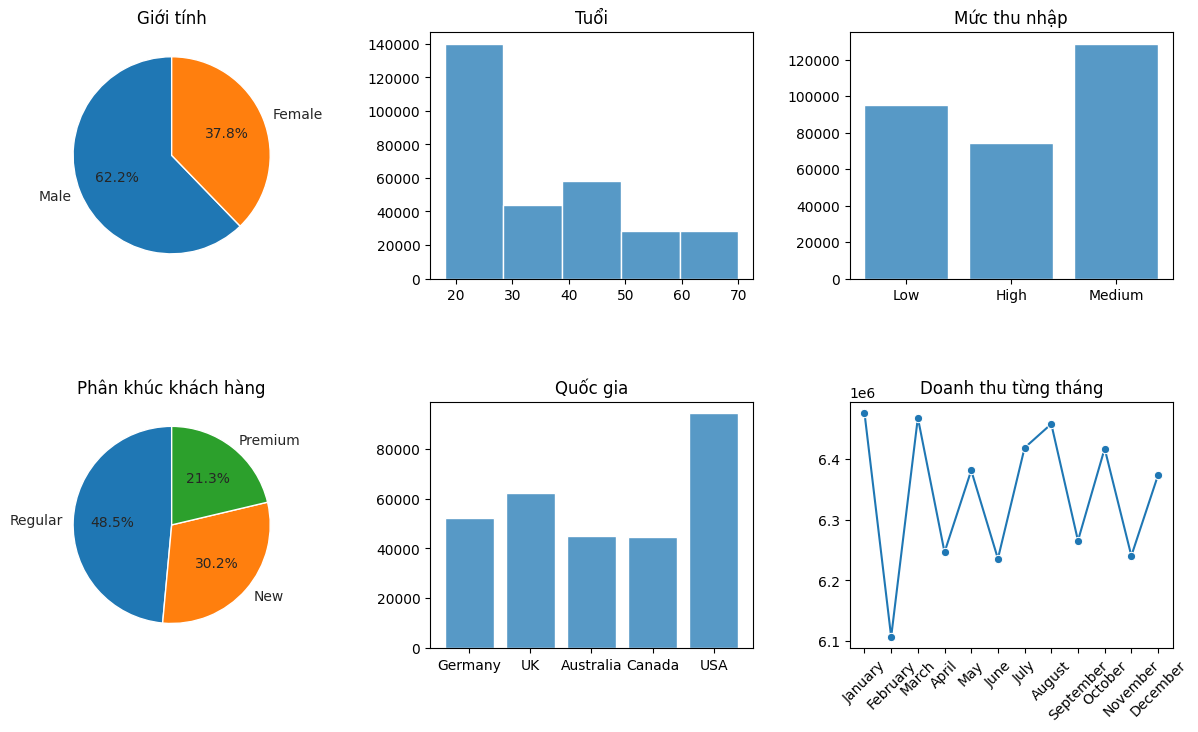

In [34]:
# Tạo figure và các subplot
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# Điều chỉnh khoảng cách giữa các hàng
plt.subplots_adjust(wspace=0.3, hspace=0.5)
sns.set_style("whitegrid")

# Biểu đồ giới tính
gender_counts = refined_df['Gender'].value_counts()
axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Giới tính')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('')

# Biểu đồ phân phối (Distribution Plots)
sns.histplot(refined_df['Age'], bins=5, ax=axes[0, 1])
axes[0, 1].set_title('Tuổi')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')

# Rating bar chart
sns.histplot(refined_df['Income'], discrete=True, ax=axes[0, 2], shrink=0.8)
axes[0, 2].set_title('Mức thu nhập')
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('')

# Product type pie chart
product_type_counts = refined_df['Customer_Segment'].value_counts()
axes[1, 0].pie(product_type_counts, labels=product_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Phân khúc khách hàng')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('')

# Country bar chart
sns.histplot(refined_df['Country'], discrete=True, ax=axes[1, 1], shrink=0.8)
axes[1, 1].set_title('Quốc gia')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')

# Line chart Amount theo Month
sns.lineplot(data=df_agg, x='Month', y='Amount', marker="o", ax=axes[1, 2])
axes[1, 2].set_title('Doanh thu từng tháng')
axes[1, 2].set_ylabel("")
axes[1, 2].set_xlabel("")
axes[1, 2].tick_params(axis='x', rotation=45)

# Hiển thị plot
plt.show()


Phân tích và trực quan hóa các biến phân loại

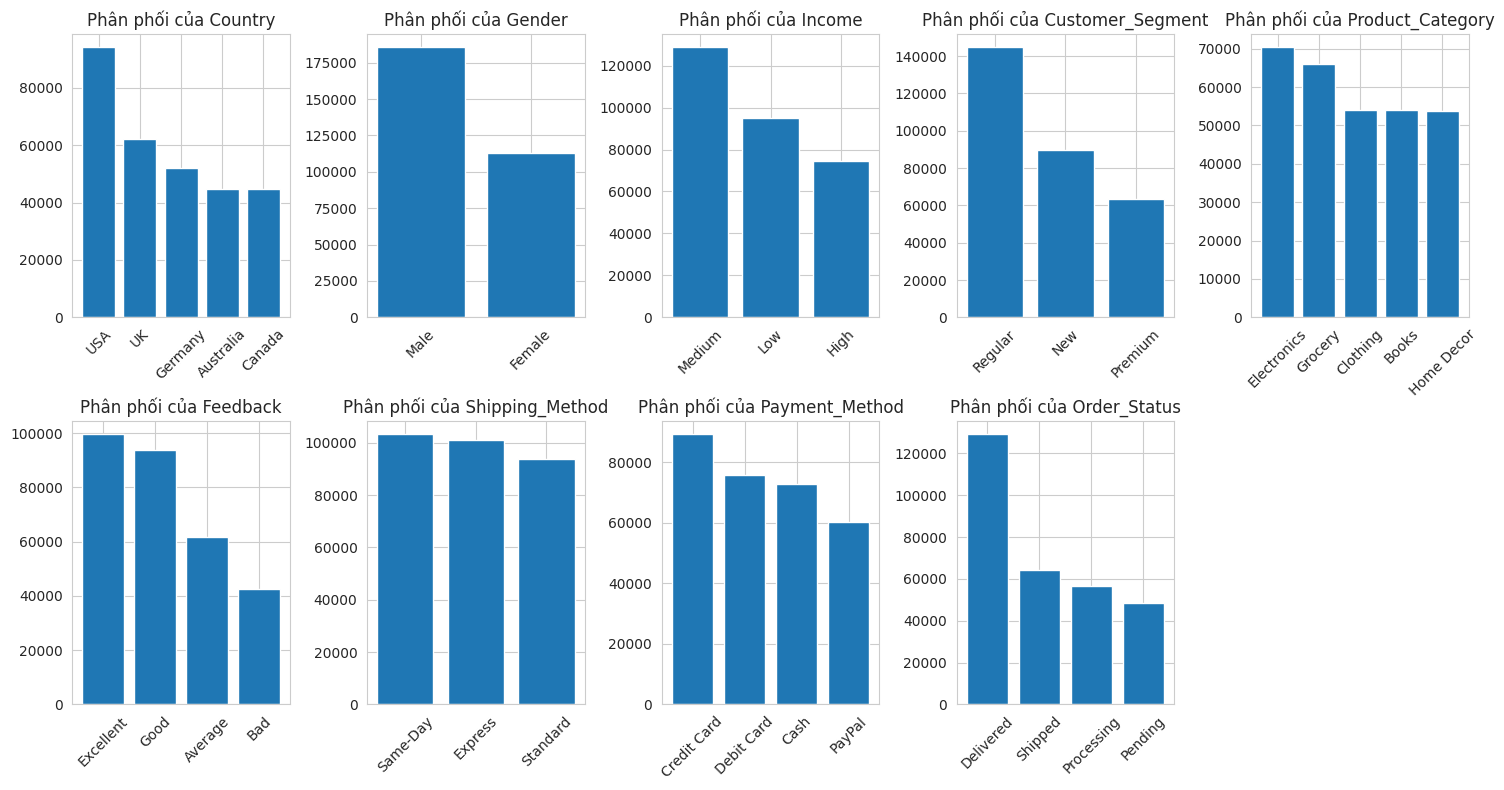

In [35]:
# Chọn các cột phân loại
categorical_columns = ['Country', 'Gender', 'Income', 'Customer_Segment',
                       'Product_Category', 'Feedback', 'Shipping_Method',
                       'Payment_Method', 'Order_Status']
plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, (len(categorical_columns) + 1) // 2, i)
    value_counts = refined_df[col].value_counts()  # Tính tần suất xuất hiện của từng giá trị trong cột col
    plt.bar(value_counts.index, value_counts.values)  # Tạo biểu đồ cột với các gtri trục x là nhãn, trục y là số lượng (tần suất)
    plt.title(f'Phân phối của {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ANOVA

## b. Phân tích nhân khẩu học

In [36]:
# Lọc đơn hàng có Order_Status là 'Delivered'
delivered_orders = refined_df[refined_df['Order_Status'] == 'Delivered']

# Chia các nhóm tuổi và gán nhãn
bins = [18, 25, 35, 45, 100]
labels = ['18-25', '25-35', '35-45', '46+']

# Tạo cột mới Age_Group cho mỗi nhóm tuổi
delivered_orders['Age_Group'] = pd.cut(delivered_orders['Age'], bins=bins, labels=labels, right=False)

# Nhóm theo từng nhóm tuổi và tính tổng tiền (Total Amount), số lượng đơn hàng (Total Purchases)
age_group_summary = delivered_orders.groupby('Age_Group').agg(
    Total_Amount_Millions=('Amount', 'sum'),
    Total_Purchases=('Age_Group', 'count')
).reset_index()

# Chuyển Total Amount sang đơn vị triệu
age_group_summary['Total_Amount_Millions'] = age_group_summary['Total_Amount_Millions'] / 1_000_000

# Sắp xếp theo Total Amount
age_group_summary = age_group_summary.sort_values(by='Total_Amount_Millions', ascending=False)

age_group_summary


<ipython-input-36-8665ca9ef859>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['Age_Group'] = pd.cut(delivered_orders['Age'], bins=bins, labels=labels, right=False)
<ipython-input-36-8665ca9ef859>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_summary = delivered_orders.groupby('Age_Group').agg(


,Age_Group,Total_Amount_Millions,Total_Purchases
0,18-25,14.107346,55303
1,25-35,8.437473,33165
3,46+,8.318441,32627
2,35-45,2.036122,7981


| Age Group | Total Amount | Total Purchase | Nhận xét |
|---|---|---|---|
| 18-25 | 14.107346	| 55.303 | Nhóm tuổi này có tổng tiền và số lượng đơn hàng cao nhất, chứng tỏ sự đóng góp mạnh mẽ của khách hàng trẻ tuổi |
| 25-35 | 8.437473 | 33.165 | Số liệu của nhóm tuổi này cũng tương đối cao nhưng giảm so với nhóm trẻ tuổi |
|	35-45	| 2.036122 | 7.981 | Nhóm tuổi này đóng góp thấp nhất, nên có những hoạt động tiếp thị... |
|	46+	| 8.318441 | 32.627 | Mặc dù số liệu của nhóm tuổi này có phần giảm nhưng cũng đóng góp một lượng đáng kể |

In [37]:
#  Nhóm theo từng thành phố và tính tổng tiền (Total Amount), số lượng đơn hàng (Total Purchases)
city_summary = delivered_orders.groupby('City').agg(
    Total_Amount_Millions=('Amount', 'sum'),
    Total_Purchases_K=('City', 'count')
).reset_index()

# Chuyển Total Amount sang đơn vị triệu
city_summary['Total_Amount_Millions'] = city_summary['Total_Amount_Millions'] / 1000000

# In
city_summary_sorted = city_summary.sort_values(by='Total_Amount_Millions', ascending=False).head(10)
city_summary_sorted

,City,Total_Amount_Millions,Total_Purchases_K
100,Portsmouth,2.973504,11687
107,San Francisco,2.527714,9899
44,Frankfurt,2.221003,8728
26,Chicago,1.383357,5461
43,Fort Worth,1.165810,4597
16,Boston,0.604834,2373
67,London,0.433046,1737
84,New York,0.379721,1483
32,Darwin,0.246396,952
127,Winnipeg,0.245366,972


| City | Total Amount | Total Purchase | Nhận xét |
|---|---|---|---|
| Portsmounth | 2.93	| 11.52 | múc độ mua sắm, mức chi tiêu cao của khách hàng tp này |
| San Francisco | 2.5 | 9.81 | nhu cầu của khách hàng và khối lượng giao dịch cao |
|	Frankfurt	| 2.19 | 8.61 | tham gia mạnh mẽ trên thị trường. |
|	Chicago	| 1.36 | 5.36 | hoạt động của khách hàng và tỷ lệ mua hàng ở mức vừa phải |
|	Fort Worth| 1.15 | 4.54 | hoạt động của khách hàng và tỷ lệ mua hàng ở mức vừa phải |
| Boston, London, New York | < 1 | < 3 | hoạt đọng còn hạn chế |
| Darwin, Victoria | < 250 | < 1 | những thị trường mới nổi |

In [38]:
#  Nhóm theo từng quốc gia và tính tổng tiền (Total Amount), số lượng đơn hàng (Total Purchases)
country_summary = delivered_orders.groupby('Country').agg(
    Total_Amount_Millions=('Amount', 'sum'),
    Total_Purchases_K=('Country', 'count')
).reset_index()

# Chuyển Total Amount sang đơn vị triệu
country_summary['Total_Amount_Millions'] = country_summary['Total_Amount_Millions'] / 1000000

# In
country_summary_sorted = country_summary.sort_values(by='Total_Amount_Millions', ascending=False)
country_summary_sorted

,Country,Total_Amount_Millions,Total_Purchases_K
4,USA,10.115428,39676
3,UK,7.262583,28495
2,Germany,6.488436,25448
0,Australia,4.536706,17714
1,Canada,4.496229,17743


| Nhóm quốc gia | Tên quốc gia | Nhận xét |
|---|---|---|
| Hiệu suất cao nhất | USA | Total Amount cao nhất gần 10M, sau đó là UK và Germany cho thấy nhu cần mạnh mẽ của thị trường |
| Lượng mua mạnh | USA | Total Purchases > 39K cho thấy nền tảng khách hàng, hoạt động mua hàng mạnh mẽ |
| Cơ hội phát triển | Australia, Canada | số liệu đáng kể, có tiềm năng mở rộng thị trường, cần chiến lược phát triển |

In [39]:
#  Nhóm theo từng phân khúc khách hàng và tính tổng tiền (Total Amount), số lượng đơn hàng (Total Purchases)
segment_summary = delivered_orders.groupby('Customer_Segment').agg(
    Total_Amount_Millions=('Amount', 'sum'),
    Total_Purchases_K=('Customer_Segment', 'count')
).reset_index()

# Chuyển Total Amount sang đơn vị triệu và Total Purchases sang đơn vị nghìn
segment_summary['Total_Amount_Millions'] = segment_summary['Total_Amount_Millions'] / 1000000

# In
segment_summary_sorted = segment_summary.sort_values(by='Total_Amount_Millions', ascending=False)
segment_summary_sorted

,Customer_Segment,Total_Amount_Millions,Total_Purchases_K
2,Regular,19.258640,75540
0,New,8.235747,32324
1,Premium,5.404995,21212


| Customer_Segment |Total Amount | Total Purchases | Nhận xét |
|---|---|---|---|
|	Regular |	18.94 |	74.32 | nguồn doanh thu chính |
|	New	| 8.08 | 31.72 | đóng góp vừa phải, có tiềm năng phát triển |
|	Premium	| 5.29 | 20.74 | cần chú ý |

<ipython-input-40-bc1594adf5c0>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_summary_sorted, x='City', y='Total_Amount_Millions', ax=ax1[0,0], palette='Blues')
<ipython-input-40-bc1594adf5c0>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_group_summary, x='Age_Group', y='Total_Amount_Millions', ax=ax1[0,1], palette='Blues')
<ipython-input-40-bc1594adf5c0>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_summary_sorted, x='Country', y='Total_Amount_Millions', ax=ax1[1,0], palette='Blues')
<ipython-input

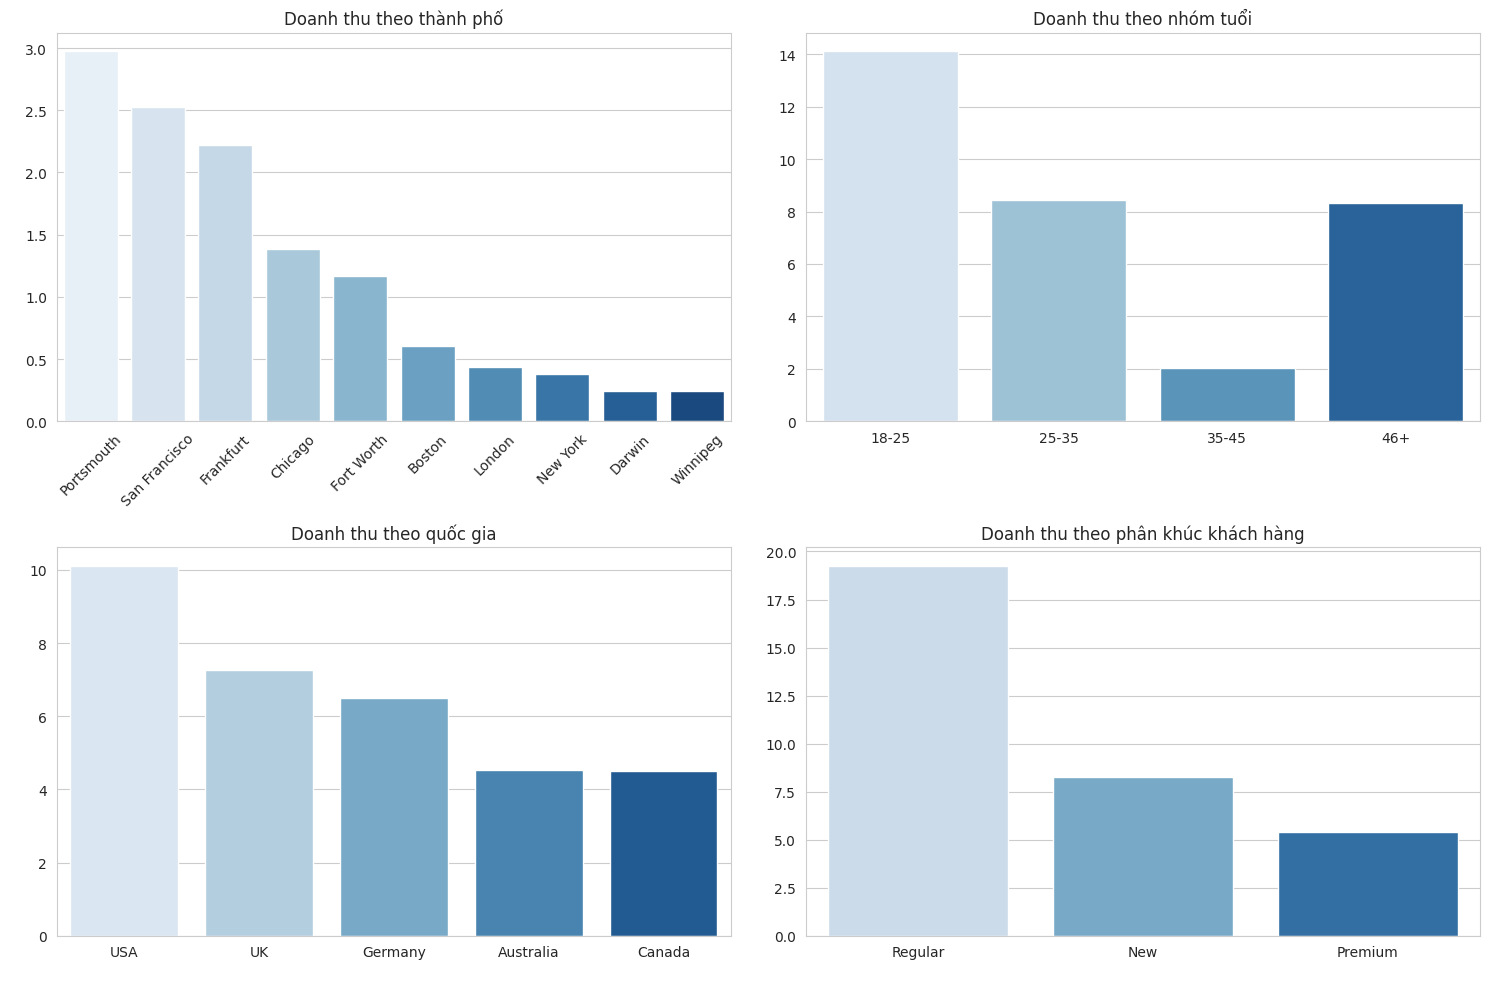

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

fig, ax1 = plt.subplots(2, 2, figsize=(15, 10))

# Hàng 1
# Biểu đồ cột Total Amount theo City
sns.barplot(data=city_summary_sorted, x='City', y='Total_Amount_Millions', ax=ax1[0,0], palette='Blues')
ax1[0,0].set_title('Doanh thu theo thành phố')
ax1[0,0].set_xlabel('')
ax1[0,0].set_ylabel('')
ax1[0,0].tick_params(axis='x', rotation=45)

# Biểu đồ cột Total Amount theo Tuổi
sns.barplot(data=age_group_summary, x='Age_Group', y='Total_Amount_Millions', ax=ax1[0,1], palette='Blues')
ax1[0,1].set_title('Doanh thu theo nhóm tuổi')
ax1[0,1].set_xlabel(' ')
ax1[0,1].set_ylabel(' ')

# Hàng 2
# Biểu đồ cột Total Amount
sns.barplot(data=country_summary_sorted, x='Country', y='Total_Amount_Millions', ax=ax1[1,0], palette='Blues')
ax1[1,0].set_title('Doanh thu theo quốc gia')
ax1[1,0].set_xlabel(' ')
ax1[1,0].set_ylabel(' ')

# Biểu đồ cột ToTal Purchases
sns.barplot(data=segment_summary_sorted, x='Customer_Segment', y='Total_Amount_Millions', ax=ax1[1,1], palette='Blues')
ax1[1,1].set_title('Doanh thu theo phân khúc khách hàng')
ax1[1,1].set_xlabel(' ')
ax1[1,1].set_ylabel(' ')

plt.tight_layout()

In [41]:
# Hàng 3: Treemap
fig = px.treemap(
    refined_df,
    path=['Country', 'State', 'City'],
    values='Amount',
    title='Treemap Doanh thu theo khu vực'
)

fig.show()

## c. Phân tích sự tương quan

In [42]:
corr_df = refined_df.copy()

Đinh nghĩa các cột phân loại với nhiều và ít giá trị

In [43]:
header_category_value = ['City', 'State', 'Country', 'Gender', 'Income', 'Customer_Segment', 'Product_Category', 'Product_Brand',
                         'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method', 'Order_Status', 'products', 'Ratings']
headers_categories_with_few_value = ['Gender', 'Income', 'Customer_Segment', 'Feedback',
                               'Shipping_Method', 'Payment_Method', 'Order_Status', 'Country', 'Ratings']
headers_categories_with_many_value = ['City', 'State', 'Product_Category', 'Product_Brand', 'Product_Type', 'products']

### Phân tích hành vi khách hàng

Mục tiêu là phân tích:
- Thời gian khách hàng mua gần đây (Recency)
- Tần suất mua hàng (Frequency)
- Tổng tiền khách hàng bỏ ra qua giai đoạn nhất định (Monetary)

**Phân tích RFM (Recency, Frequency, Monetary)**

Phân tích RFM là một kỹ thuật mạnh mẽ để phân khúc khách hàng dựa trên hành vi mua sắm của họ, cho phép các doanh nghiệp tùy chỉnh chiến lược tiếp thị và cải thiện sự gắn kết của khách hàng. Dưới đây là các chỉ số liên quan:

- **Recency (R) - Gần đây**
  - Chỉ số này đo lường khoảng thời gian từ lần mua hàng gần nhất của khách hàng.
  - Khách hàng mua hàng gần đây thường có mức độ gắn kết cao hơn và khả năng phản hồi với các chiến dịch tiếp thị tốt hơn.

- **Frequency (F) - Tần suất**
  - Chỉ số này đếm số lần khách hàng mua hàng trong một khoảng thời gian cụ thể.
  - Tần suất cao cho thấy lòng trung thành và sự hài lòng mạnh mẽ từ khách hàng, vì họ quay lại mua hàng thường xuyên.
  - Theo dõi tần suất giúp xác định cơ hội để tăng cường mối quan hệ với các khách hàng trung thành.

- **Monetary (M) - Giá trị**
  - Chỉ số này đo tổng số tiền mà một khách hàng đã chi tiêu trong một khoảng thời gian cụ thể.
  - Khách hàng chi tiêu nhiều hơn thường có giá trị cao hơn đối với doanh nghiệp.
  - Phân tích giá trị giúp ưu tiên các khách hàng giá trị cao để thực hiện chiến lược giữ chân và tiếp thị cá nhân hóa.


In [44]:
latest_date = corr_df['Date'].max()  # Chọn đơn hàng gần nhất làm mốc để tính Recency
rfm = corr_df.groupby('new_customer_id').agg(
    Recency=('Date', lambda x: (latest_date - x.max()).days),  # Chọn đơn hàng gần nhất làm mốc để tính Recency
    Frequency=('new_transaction_id', 'count'), # Tính tần suất mua hàng dựa trên số đơn hàng
    Monetary=('Total_Amount', 'sum') # Tính tổng doanh thu
).reset_index()
rfm.head()

,new_customer_id,Recency,Frequency,Monetary
0,0,164,1,324.086270
1,1,60,1,806.707815
2,2,309,1,1063.432799
3,3,297,1,2466.854021
4,4,50,1,248.553049


**Sử dụng mô hình gom nhóm K-Means để chia phân khúc khách hàng dựa trên các chỉ số Recenct, Frequency, Monetary**

In [45]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Sử dụng mô hình gom nhóm K-Means với 3 nhóm
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

segment_mapping = {
    0: 'Passive Customers',
    1: 'New Customers',
    2: 'High-Value Customers',
}
rfm['Segment_Name'] = rfm['Segment'].map(segment_mapping)

# Sắp xếp các giá trị RFM
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False)

**Phân tích các nhóm khách hàng**

In [46]:
# Gom nhóm để quan sát ['Recency', 'Frequency', 'Monetary']
segment_stats = rfm.groupby('Segment_Name')[['Recency', 'Frequency', 'Monetary']].describe()
segment_stats.T

Segment_Name     High-Value Customers  New Customers  Passive Customers
Recency   count          66116.000000  115727.000000      115313.000000
          mean             182.454792      87.961755         276.992898
          std               96.435720      52.799097          52.655792
          min                0.000000       0.000000         183.000000
          25%              106.000000      42.000000         232.000000
          50%              183.000000      87.000000         278.000000
          75%              259.000000     133.000000         323.000000
          max              365.000000     182.000000         365.000000
Frequency count          66116.000000  115727.000000      115313.000000
          mean               1.014626       1.000000           1.000000
          std                0.120050       0.000000           0.000000
          min                1.000000       1.000000           1.000000
          25%                1.000000       1.000000           1.000000
          50%                1.000000       1.000000           1.000000
          75%                1.000000       1.000000           1.000000
          max                2.000000       1.000000           1.000000
Monetary  count          66116.000000  115727.000000      115313.000000
          mean            3105.339303     873.167492         879.999290
          std              772.455463     615.859399         621.405541
          min               21.975152      10.011336          10.003750
          25%             2529.971821     350.319507         351.654181
          50%             2983.857732     753.891965         758.774186
          75%             3614.149838    1329.096358        1341.197243
          max             9873.066372    2651.464352        2669.357630

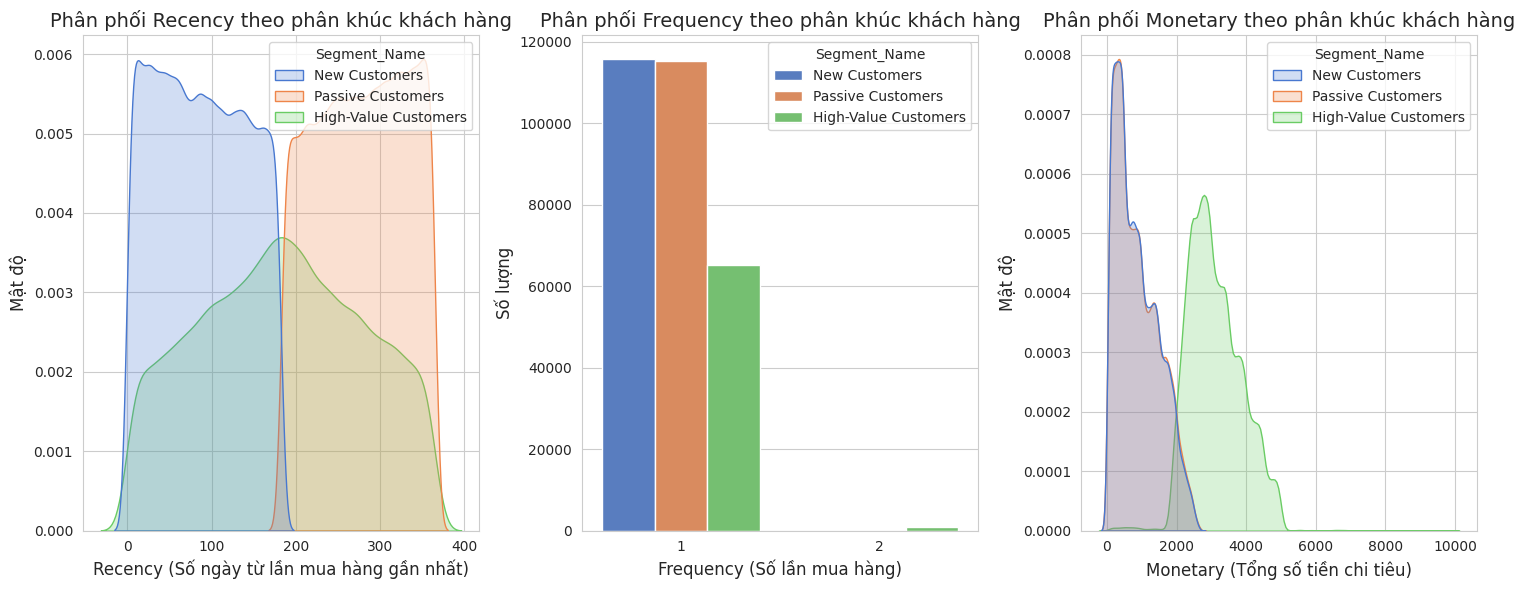

In [47]:
# Tạo biểu đồ density cho Recency, Frequency và Monetary theo Segment
fig, axis = plt.subplots(1, 3, figsize=(15, 6))
axis = axis.flatten()

# Biểu đồ Density cho Recency
sns.kdeplot(data=rfm, x='Recency', hue='Segment_Name', fill=True, common_norm=False, palette="muted", ax=axis[0])
axis[0].set_title('Phân phối Recency theo phân khúc khách hàng', fontsize=14)
axis[0].set_xlabel('Recency (Số ngày từ lần mua hàng gần nhất)', fontsize=12)
axis[0].set_ylabel('Mật độ', fontsize=12)

# Biểu đồ Density cho Frequency
sns.countplot(data=rfm, x='Frequency', hue='Segment_Name', palette="muted", ax=axis[1])
axis[1].set_title('Phân phối Frequency theo phân khúc khách hàng', fontsize=14)
axis[1].set_xlabel('Frequency (Số lần mua hàng)', fontsize=12)
axis[1].set_ylabel('Số lượng', fontsize=12)

# Biểu đồ Density cho Monetary
sns.kdeplot(data=rfm, x='Monetary', hue='Segment_Name', fill=True, common_norm=False, palette="muted", ax=axis[2])
axis[2].set_title('Phân phối Monetary theo phân khúc khách hàng', fontsize=14)
axis[2].set_xlabel('Monetary (Tổng số tiền chi tiêu)', fontsize=12)
axis[2].set_ylabel('Mật độ', fontsize=12)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

**Sử dụng phân tích ANOVA với thư viện f_classif**
(f_classif trong sklearn phục vụ cho mục đích chọn lọc đặc trưng trong bài toán phân loại với nhiều lớp)
- Ta giả sử cho những khách hàng chưa mua tháng trong gần 6 tháng có nguy cơ rời bỏ

In [48]:
# Ghép dữ liệu mới phân chia khách hàng với dữ liệu gốc
new_customer_segment_df = corr_df.merge(rfm, on='new_customer_id')

# High_Risk_Of_Churn cho những khách hàng chưa mua hàng trong 6 tháng
new_customer_segment_df['High_Risk_Of_Churn'] = new_customer_segment_df['Recency'].apply(lambda x: 1 if x > 180 else 0)

# Những cột không liên quan
columns_to_drop = [
    'new_customer_id', 'new_transaction_id', # id
    'Name', 'Email', 'Phone', # thông tin cá nhân
    'Address', 'Zipcode',  # địa chỉ cụ thể
    'Segment_Name', 'Segment', 'Recency', 'Frequency', 'Monetary',  # những cột mới thêm trong khi phân nhóm
    'Birth', 'Time', 'Date' # Dữ liệu ngày cụ thể
]
new_customer_segment_df_clean = new_customer_segment_df.drop(columns=columns_to_drop)


new_customer_segment_df_clean['Month'] = new_customer_segment_df_clean['Month'].astype('category')
new_customer_segment_df_encoded = new_customer_segment_df_clean.copy()

# Mã hóa các cột (nếu nhiều thì sử dụng mã hóa target, ít thì label encode)
for header in new_customer_segment_df_encoded.columns:
    if header in headers_categories_with_few_value:
        new_customer_segment_df_encoded[header] = label_encode_one_column(new_customer_segment_df_encoded[header])
    elif header in headers_categories_with_many_value:
        new_customer_segment_df_encoded = target_encode_columns(new_customer_segment_df_encoded, [header], 'High_Risk_Of_Churn')

In [49]:
# Xác định features and target
X = new_customer_segment_df_encoded.drop(columns=['High_Risk_Of_Churn'])  # Features
y = new_customer_segment_df_encoded['High_Risk_Of_Churn']  # Target

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ANOVA F-test để chọn features
f_values, p_values = f_classif(X_scaled, y)

# F-values and p-values
anova_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Value': f_values,
    'P-Value': p_values
})

anova_df = anova_df.sort_values(by=['F-Value', 'P-Value'], ascending=[False, True])
anova_df[['Feature', 'F-Value', 'P-Value']]

,Feature,F-Value,P-Value
7,Year,75169.934077,0.000000e+00
8,Month,26783.091178,0.000000e+00
20,products,326.668528,5.590755e-73
0,City,99.981095,1.551795e-23
1,State,67.154310,2.520451e-16
14,Product_Type,38.964463,4.321687e-10
13,Product_Brand,28.578745,9.003020e-08
12,Product_Category,9.986807,1.576815e-03
9,Total_Purchases,5.228471,2.222075e-02
18,Order_Status,5.011792,2.517597e-02


**Từ bảng thống kê trên, ta chọn (lý do dựa trên top các f-value cao nhất mà có hệ số p mạnh < 0.05 và f >= 5):**
1. 'Year'
2. 'Month'
3. 'products'
4. 'City'
5. 'State'
6. 'Product_Type'
7. 'Product_Brand'
8. 'Product_Category'
9. 'Total_Purchases'
10.'Order_Status'

In [50]:
header_choosen_recency_customer = [
    'Year', 'Month', 'products', 'City', 'State', 'Product_Type', 'Product_Brand', 'Product_Category', 'Total_Purchases', 'Order_Status'
]

# III. Xây dựng mô hình

In [57]:
  def r2_better_r2_score(r2_compare, r2_root):
    return 1 - (r2_root) > 1 - (r2_compare)

In [58]:
training_model_df = refined_df.copy()

## a/ Dự đoán rủi ro khách hàng rời đi

In [59]:
# Xây dựng mô hình cho Churn Risk (Rủi ro mất khách)
header_choosen_recency_customer = ['Year', 'Month', 'products', 'City', 'State', 'Product_Type', 'Product_Brand']

In [62]:
latest_order_date = training_model_df['Date'].max()
recency_df = training_model_df.groupby('new_customer_id').agg(
    Recency=('Date', lambda x: (latest_order_date - x.max()).days),
).reset_index()
recency_df['High_Risk_Of_Churn'] = recency_df['Recency'].apply(lambda x: 1 if x > 180 else 0)
recency_df[header_choosen_recency_customer] = training_model_df[header_choosen_recency_customer]
recency_df.dropna(inplace=True)

for header in recency_df.columns:
    if header in headers_categories_with_few_value:
        recency_df[header] = label_encode_one_column(recency_df[header])
    elif header in headers_categories_with_many_value:
        recency_df = target_encode_columns(recency_df, [header], 'High_Risk_Of_Churn')

X = recency_df[header_choosen_recency_customer]
y = recency_df['High_Risk_Of_Churn']

###### Mô hình Linear Regression

Linear Regression....
Polynomial Regression (degree=2)....
Polynomial Regression (degree=3)....
Polynomial Regression (degree=4)....


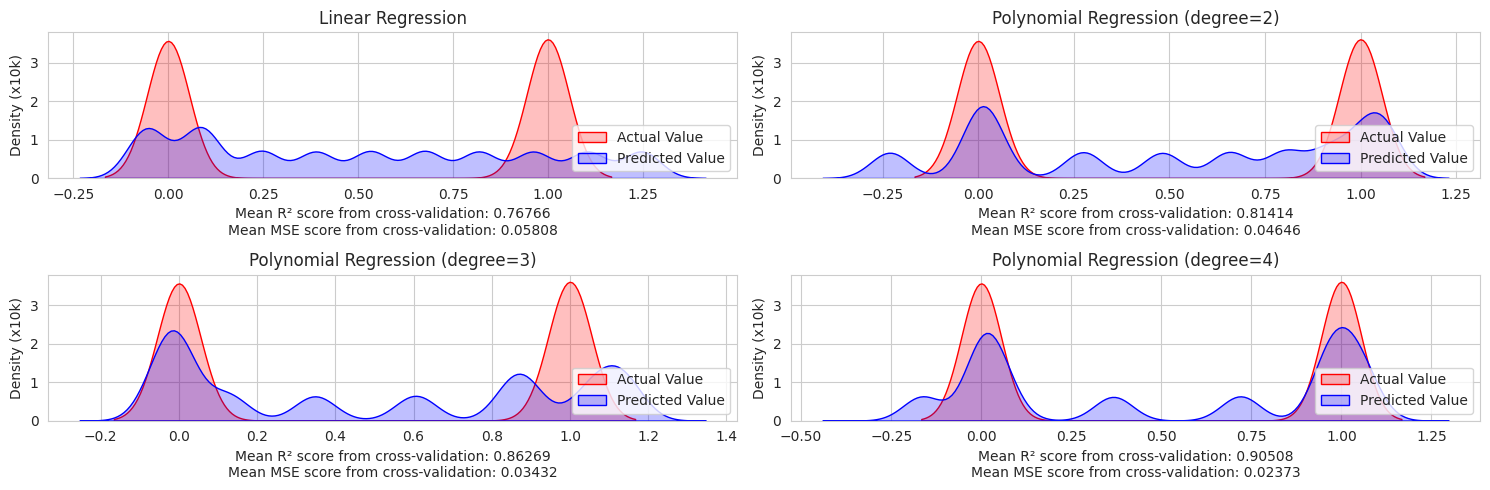

In [63]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_degrees = [1, 2, 3, 4]
best_model = None
best_score = -10000
best_model_type = ''
col = 2
row = (len(poly_degrees) + col - 1) // col
fig, axis = plt.subplots(row, col, figsize=(15, 5))
fig.tight_layout(h_pad = 10.0, w_pad=5.0)
axis = axis.flatten()

for idx, degree in enumerate(poly_degrees):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree)),
        ('model', LinearRegression())
    ])

    X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size = 0.2, random_state=1
    )
    pipe.fit(X_train, y_train)
    y_test_predict = pipe.predict(X_test)

    cv_scores_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_scores_mse = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')

    title_score = f'Mean R² score from cross-validation: {cv_scores_r2.mean():.5f}' + '\n'
    title_score += f'Mean MSE score from cross-validation: {abs(cv_scores_mse.mean()):.5f}'

    if (degree == 1):
        title = f'Linear Regression'
    else:
        title = f'Polynomial Regression (degree={degree})'

    # Cập nhật mô hình tốt nhất
    mean_score = cv_scores_r2.mean()
    if r2_better_r2_score(mean_score, best_score):
      best_score = mean_score
      best_model = pipe
      best_model_type = title

    print(title + '....')

    ax = axis[idx]
    sns.kdeplot(y_test, label="Actual Value", color="red", ax=ax, fill=True)
    sns.kdeplot(y_test_predict, label="Predicted Value", color="blue", ax=ax, fill=True)
    ax.legend(loc='lower right')
    ax.set_xlabel(title_score)
    ax.set_ylabel("Density (x10k)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

###### Mô hình Logsitic Regression

Logistic Regression....
Polynomial Logistic Regression (degree=2)....


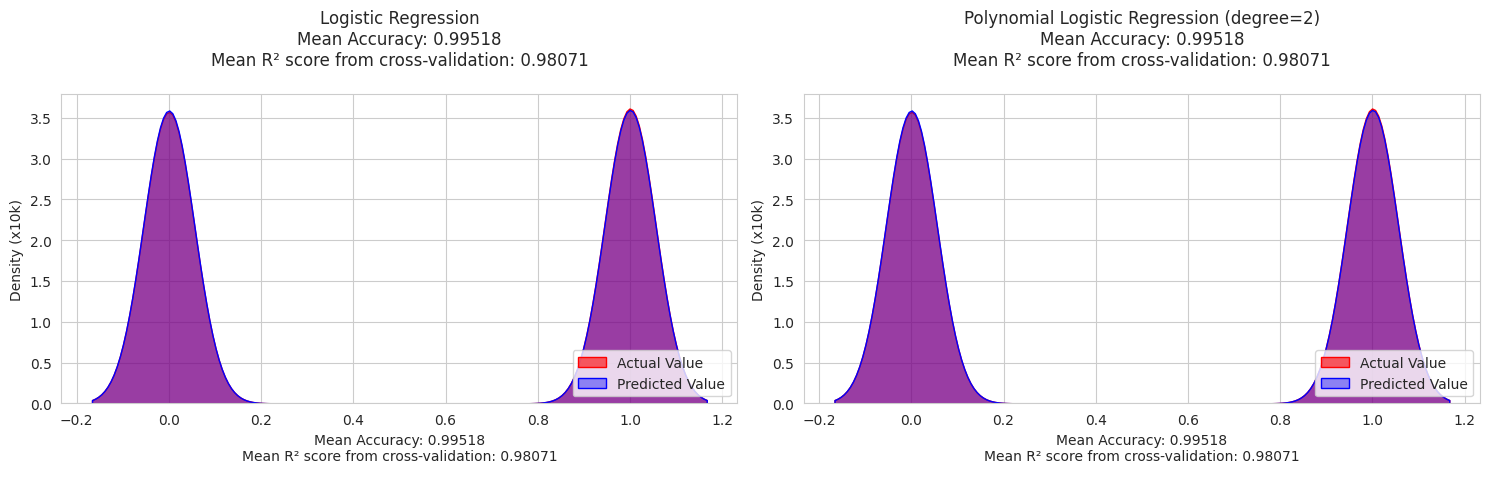

Best Model: Logistic Regression with R2 Score: 0.98071


In [64]:
from sklearn.model_selection import train_test_split, cross_val_score

# Các bậc đa thức cần thử nghiệm
poly_degrees = [1, 2]
col = 2
row = (len(poly_degrees) + col - 1) // col

fig, axis = plt.subplots(row, col, figsize=(15, 5))
fig.tight_layout(h_pad=10.0, w_pad=5.0)
axis = axis.flatten()

# Lặp qua từng bậc đa thức
for idx, degree in enumerate(poly_degrees):
    pipe = Pipeline([
        ('scaler', StandardScaler()),  # Chuẩn hóa dữ liệu
        ('poly', PolynomialFeatures(degree=degree)),  # Tạo các đặc trưng đa thức
        ('model', LogisticRegression(max_iter=1000))  # Mô hình hồi quy logistic
    ])

    # Chia dữ liệu train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=1
    )
    # Huấn luyện mô hình
    pipe.fit(X_train, y_train)
    y_test_predict = pipe.predict(X_test)

    # Đánh giá bằng cross-validation
    cv_scores_acc = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_scores_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')

    # Tiêu đề hiển thị trên biểu đồ
    title_score = f'Mean Accuracy: {cv_scores_acc.mean():.5f}\n'
    title_score += f'Mean R² score from cross-validation: {cv_scores_r2.mean():.5f}\n'

    if degree == 1:
        title = 'Logistic Regression'
    else:
        title = f'Polynomial Logistic Regression (degree={degree})'

    # Cập nhật mô hình tốt nhất
    mean_score = cv_scores_r2.mean()
    if r2_better_r2_score(mean_score, best_score):
      best_score = mean_score
      best_model = pipe
      best_model_type = title

    print(title + '....')

    # Vẽ biểu đồ so sánh
    ax = axis[idx]
    sns.kdeplot(y_test, label="Actual Value", color="red", ax=ax, alpha=0.6, fill=True)
    sns.kdeplot(y_test_predict, label="Predicted Value", color="blue", ax=ax, alpha=0.4, fill=True)
    ax.legend(loc='lower right')
    ax.set_xlabel(title_score)
    ax.set_ylabel("Density (x10k)")
    ax.set_title(title + '\n' + title_score)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# Kết quả mô hình tốt nhất
print(f"Best Model: {best_model_type} with R2 Score: {best_score:.5f}")

###### Mô hình Ridge Regression With Cross-Validation

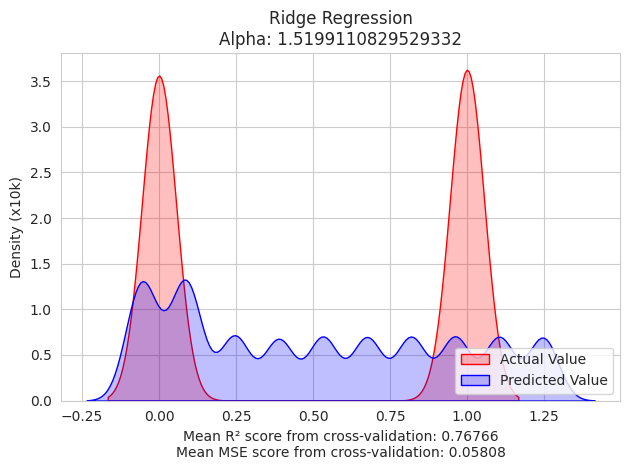

In [65]:
# Giá trị alpha để kiểm tra
alphas = np.logspace(-3, 4, 100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.sort_index(inplace=True)
X_test.sort_index(inplace=True)
y_train.sort_index(inplace=True)
y_test.sort_index(inplace=True)

# RidgeCV
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, scoring='r2', cv=5))
])
pipe.fit(X_train, y_train)

ridge_model = pipe.named_steps['model']

# Đánh giá Ridge Regression qua Cross-validation
cv_scores_ridge_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
cv_scores_ridge_mse = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')

ridge_mean_r2 = cv_scores_ridge_r2.mean()
ridge_mean_mse = -cv_scores_ridge_mse.mean()

# Lấy alpha tốt nhất
best_alpha = ridge_model.alpha_
title = 'Ridge Regression' + '\n' + f'Alpha: {best_alpha}'

if r2_better_r2_score(ridge_mean_r2, best_score):
  best_score = ridge_mean_r2
  best_model = pipe
  best_model_type = title

# Dự đoán và đánh giá
y_pred_ridge = pipe.predict(X_test)

title_score = f'Mean R² score from cross-validation: {ridge_mean_r2:.5f}' + '\n'
title_score += f'Mean MSE score from cross-validation: {ridge_mean_mse:.5f}'

sns.kdeplot(y_test, label="Actual Value", color="red", fill=True)
sns.kdeplot(y_pred_ridge, label="Predicted Value", color="blue", fill=True)
plt.legend(loc='lower right')
plt.title(title)
plt.xlabel(title_score)
plt.ylabel("Density (x10k)")

# Hiển thị đồ thị
plt.tight_layout()
plt.show()

##### Mô hình với chỉ số R2 trung bình tốt nhất

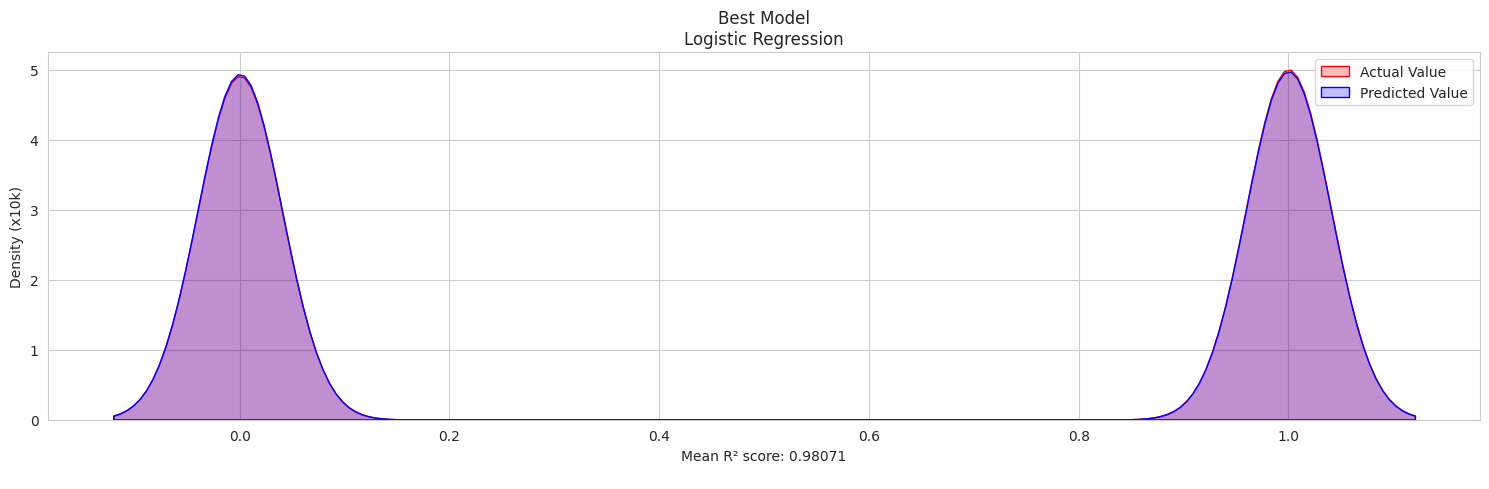

In [66]:
X.sort_index(inplace=True)
y.sort_index(inplace=True)

plt.figure(figsize=(15, 5))
y_hat = best_model.predict(X)

title_score = f'Mean R² score: {best_score:.5f}' + '\n'
sns.kdeplot(y, label="Actual Value", color="red", fill=True)
sns.kdeplot(y_hat, label="Predicted Value", color="blue", fill=True)

title = 'Best Model' + '\n' + best_model_type
plt.title(title)
plt.xlabel(title_score)
plt.ylabel("Density (x10k)")

plt.legend()
plt.tight_layout()
plt.show()

In [72]:
import gc
gc.collect()

18611

## b/ Dự báo doanh số

### 1/Bằng mô hình hồi quy tuyến tính đơn thức và đa thức và Ridge

In [67]:
# Tạo dữ liệu chuỗi thời gian từ các đơn hàng đã giao với 'Datetime' và 'Total_Amount'
time_series = training_model_df[['Date', 'Total_Amount']]

# Đặt 'Datetime' làm chỉ số (index)
time_series.set_index('Date', inplace=True)

# Sắp xếp dữ liệu theo chỉ số 'Datetime'
time_series = time_series.sort_index()

# Resample (tái mẫu) dữ liệu theo ngày - resample('D') và tính tổng 'Total_Amount', chuyển đổi sang K (nghìn)
daily_sale_df = time_series.resample('D').sum() / 1000

In [68]:
# Số lag cần sử dụng (chu kỳ lặp lại)
n_lags = 4

# Tạo các giá trị trễ làm đặc trưng
for lag in range(1, n_lags + 1):
    daily_sale_df[f'lag_{lag}'] = daily_sale_df['Total_Amount'].shift(lag)

# Bỏ các giá trị NaN do tạo lag
daily_sale_df = daily_sale_df.dropna()

# Tách đặc trưng (X) và nhãn (y)
X = daily_sale_df[[f'lag_{i}' for i in range(1, n_lags + 1)]]
y = daily_sale_df['Total_Amount']

# Đảm bảo X và y có index trùng khớp với 'Datetime'
X.index = daily_sale_df.index
y.index = daily_sale_df.index

###### Mô hình Linear Regression

Linear Regression....
Polynomial Regression (degree=2)....
Polynomial Regression (degree=3)....
Polynomial Regression (degree=4)....


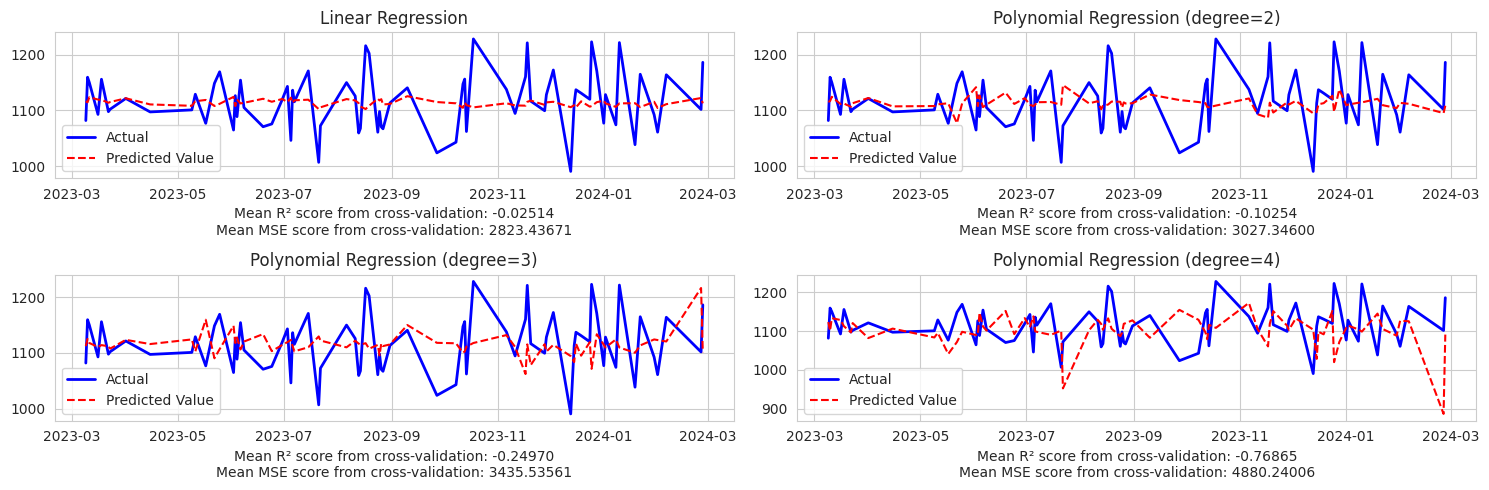

In [69]:
poly_degrees = [1, 2, 3, 4]
best_model = None
best_score = -10000
best_model_type = ''
col = 2
row = (len(poly_degrees) + col - 1) // col
fig, axis = plt.subplots(row, col, figsize=(15, 5))
fig.tight_layout(h_pad = 10.0, w_pad=5.0)
axis = axis.flatten()

for idx, degree in enumerate(poly_degrees):
  if (degree == 1):
    title = f'Linear Regression'
  else:
    title = f'Polynomial Regression (degree={degree})'

  pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=degree)),
    ('model', LinearRegression())
  ])

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size = 0.2, random_state=1
  )

  X_train.sort_index(inplace=True)
  y_train.sort_index(inplace=True)
  X_test.sort_index(inplace=True)
  y_test.sort_index(inplace=True)

  pipe.fit(X_train, y_train)
  y_test_predict = pipe.predict(X_test)

  cv_scores_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
  cv_scores_mse = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')

  mean_score = cv_scores_r2.mean()
  if r2_better_r2_score(mean_score, best_score):
    best_score = mean_score
    best_model = pipe
    best_model_type = title

  title_score = f'Mean R² score from cross-validation: {mean_score:.5f}' + '\n'
  title_score += f'Mean MSE score from cross-validation: {abs(cv_scores_mse.mean()):.5f}'

  print(title + '....')

  ax = axis[idx]
  ax.plot(y_test.index, y_test, label="Actual", color="blue", linewidth=2)
  ax.plot(y_test.index, y_test_predict, label="Predicted Value", color="red", linestyle="--")
  ax.legend()
  ax.set_xlabel(title_score)
  ax.set_title(title)

plt.tight_layout()
plt.show()


###### Mô hình Ridge Regression With Cross-Validation

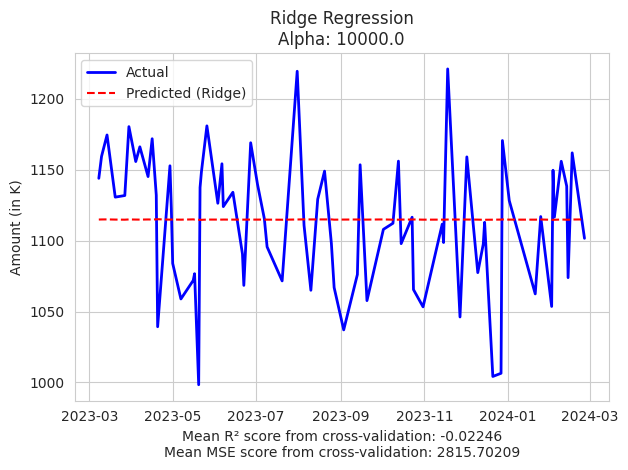

In [70]:
# Giá trị alpha để kiểm tra
alphas = np.logspace(-  3, 4, 100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.sort_index(inplace=True)
y_train.sort_index(inplace=True)
X_test.sort_index(inplace=True)
y_test.sort_index(inplace=True)

# RidgeCV
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, scoring='r2', cv=5))
])
pipe.fit(X_train, y_train)

ridge_model = pipe.named_steps['model']

# Đánh giá Ridge Regression qua Cross-validation
cv_scores_ridge_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
cv_scores_ridge_mse = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')

ridge_mean_r2 = cv_scores_ridge_r2.mean()
ridge_mean_mse = -cv_scores_ridge_mse.mean()

# Lấy alpha tốt nhất
best_alpha = ridge_model.alpha_
title = 'Ridge Regression' + '\n' + f'Alpha: {best_alpha}'

if r2_better_r2_score(ridge_mean_r2, best_score):
  best_score = ridge_mean_r2
  best_model = pipe
  best_model_type = title

# Dự đoán và đánh giá
y_pred_ridge = pipe.predict(X_test)

title_score = f'Mean R² score from cross-validation: {ridge_mean_r2:.5f}' + '\n'
title_score += f'Mean MSE score from cross-validation: {ridge_mean_mse:.5f}'

plt.plot(y_test.index, y_test, label="Actual", color="blue", linewidth=2)
plt.plot(y_test.index, y_pred_ridge, label="Predicted (Ridge)", color="red", linestyle="--")
plt.title(title)
plt.xlabel(title_score)
plt.ylabel("Amount (in K)")
plt.legend()

# Hiển thị đồ thị
plt.tight_layout()
plt.show()

##### Best Model

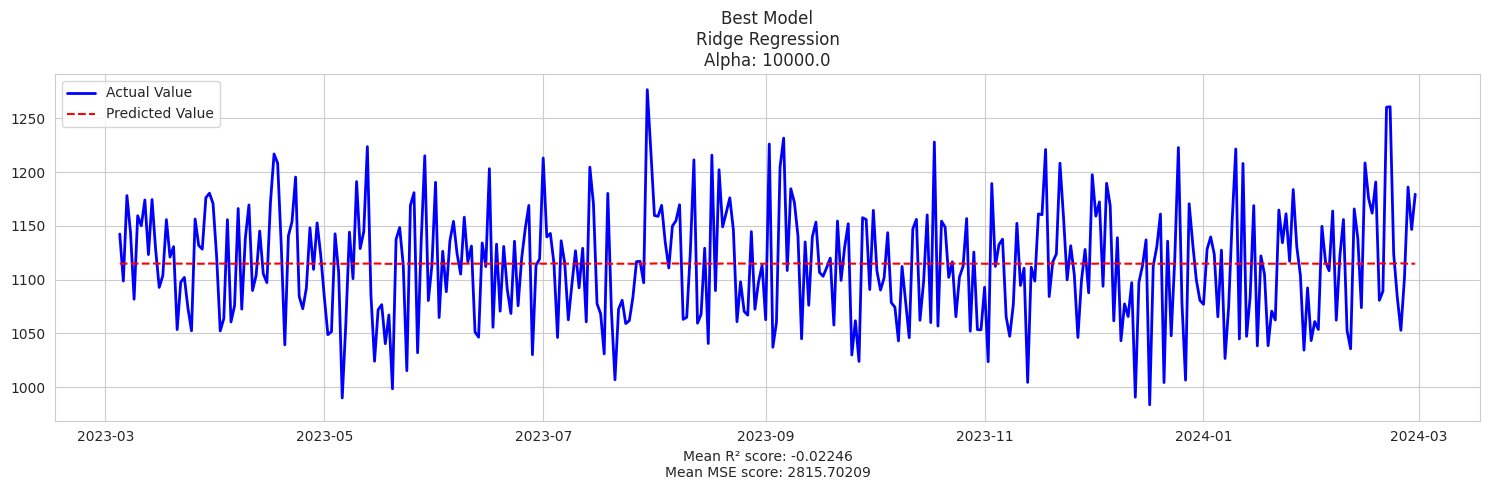

In [71]:
plt.figure(figsize=(15, 5))
y_hat = best_model.predict(X)

cv_scores_r2 = cross_val_score(best_model, X, y, cv=5, scoring='r2')
cv_scores_mse = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
valid_score = [score for score in cv_scores_r2 if score >= 0]

title_score = f'Mean R² score: {cv_scores_r2.mean():.5f}' + '\n'
title_score += f'Mean MSE score: {abs(cv_scores_mse.mean()):.5f}'
plt.plot(y.index, y, label="Actual Value", color="blue", linewidth=2)
plt.plot(y.index, y_hat, label="Predicted Value", color="red", linestyle="--")

title = 'Best Model' + '\n' + best_model_type
plt.title(title)
plt.xlabel(title_score)

plt.legend()
plt.tight_layout()
plt.show()

### 2/ Dự đoán doanh thu trong 30 ngày tới kể từ đơn hàng gần nhất với mô hình ARIMA

In [73]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.5 MB/s eta 0:00:00


In [74]:
import pmdarima as pm

# Tìm kiếm qua các bậc mô hình
results = pm.auto_arima(daily_sale_df['Total_Amount'], # dữ liệu
                        seasonal=True, # chuỗi thời gian có tính mùa vụ
                        m=4, # chu kỳ mùa vụ
                        d=0, # số lần sai phân mùa vụ (chuỗi thời gian là tính dừng => 0)
                        D=0, # số lần sai phân theo mùa vụ (chuỗi thời gian là tính dừng => 0)

                        start_p=1, # ước lượng ban đầu cho P, (Số bậc của phần AR, quyết định dựa trên PACF)
                        start_q=1, # ước lượng ban đầu cho Q, (Số bậc của phần MA, quyết định dựa trên ACF)

                        max_p=4, # giá trị tối đa của P để thử nghiệm, Bậc AR tối đa
                        max_q=4, # giá trị tối đa của Q để thử nghiệm, Bậc AM tối đa

                        information_criterion='bic', # tiêu chí thông tin dùng để chọn mô hình tốt nhất
                        trace=False, # in ra kết quả trong quá trình huấn luyện
                        error_action='ignore', # bỏ qua các bậc mô hình không hoạt động
                        stepwise=True, # tìm kiếm theo bước
                       )
print(results)
print(results.summary())

 ARIMA(0,0,0)(0,0,0)[4] intercept
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  362
Model:                        SARIMAX   Log Likelihood               -1949.571
Date:                Sat, 14 Dec 2024   AIC                           3903.142
Time:                        10:22:13   BIC                           3910.926
Sample:                    03-05-2023   HQIC                          3906.236
                         - 02-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1114.5536      2.797    398.469      0.000    1109.071    1120.036
sigma2      2788.4311    223.463     12.478      0.000    2350.451    3226.411
Ljung-Box (L1) (Q)

#### Giải thích các biểu đồ chẩn đoán

Kết quả trả về từ hàm `plot_diagnostics` của mô hình ARIMA/SARIMA là các biểu đồ giúp kiểm tra chất lượng của mô hình. Các biểu đồ này rất quan trọng trong việc đánh giá xem mô hình đã phù hợp với dữ liệu hay chưa.

#### Các biểu đồ:

1. **Biểu đồ Residuals vs. Fitted (Dư so với Giá trị dự báo):**
    - Biểu đồ này giúp kiểm tra sự phân bố của phần dư (residuals) so với các giá trị dự báo.
    - **Nhận xét:** Nếu phần dư phân tán xung quanh đường ngang 0 mà không có sự phân biệt rõ ràng, mô hình là hợp lý. Nếu có mô hình hóa sai, phần dư sẽ không phân bố ngẫu nhiên và có thể có xu hướng hoặc cấu trúc rõ rệt.

2. **Biểu đồ Histogram of Residuals (Biểu đồ tần suất của phần dư):**
    - Biểu đồ này cho thấy phân phối của phần dư, giúp đánh giá xem phần dư có phân phối chuẩn (normal) hay không.
    - **Nhận xét:** Nếu phần dư phân phối chuẩn (hoặc gần chuẩn), mô hình có thể hợp lý. Phần dư không chuẩn có thể chỉ ra rằng mô hình chưa phù hợp và cần điều chỉnh.

3. **Biểu đồ QQ Plot (Biểu đồ QQ):**
    - QQ-plot kiểm tra xem phần dư có phân phối chuẩn hay không. Nếu các điểm trong đồ thị nằm trên một đường thẳng, điều đó có nghĩa là phần dư tuân theo phân phối chuẩn.
    - **Nhận xét:** Nếu các điểm gần đường chéo 45 độ, điều này cho thấy phần dư tuân theo phân phối chuẩn, điều này rất quan trọng trong các mô hình dự báo.

4. **Biểu đồ Autocorrelation của phần dư (Residuals Autocorrelation):**
    - Biểu đồ này giúp kiểm tra xem có sự tự tương quan trong phần dư hay không. Nếu phần dư là white noise, các giá trị tự tương quan (ACF) sẽ không có sự tương quan đáng kể ở bất kỳ độ trễ nào.
    - **Nhận xét:** Nếu phần dư không có tự tương quan (ACF gần bằng 0 tại tất cả các độ trễ), mô hình là phù hợp. Nếu có tự tương quan, mô hình cần cải thiện.

---

### Kết luận:

- **Biểu đồ Residuals vs Fitted:** Phần dư không có xu hướng rõ ràng và phân bố ngẫu nhiên quanh 0, điều này cho thấy mô hình phù hợp với dữ liệu.
- **Biểu đồ Histogram of Residuals:** Phần dư có phân phối gần với phân phối chuẩn, điều này cũng xác nhận tính hợp lý của mô hình.
- **Biểu đồ QQ Plot:** Các điểm nằm gần đường chéo, chứng tỏ phần dư tuân theo phân phối chuẩn.
- **Biểu đồ Autocorrelation của phần dư:** Phần dư không có sự tự tương quan, cho thấy mô hình không bỏ sót thông tin quan trọng.

Tóm lại, các biểu đồ chẩn đoán này cho thấy mô hình ARIMA/SARIMA đã được xây dựng là phù hợp và không có vấn đề nghiêm trọng với phần dư.


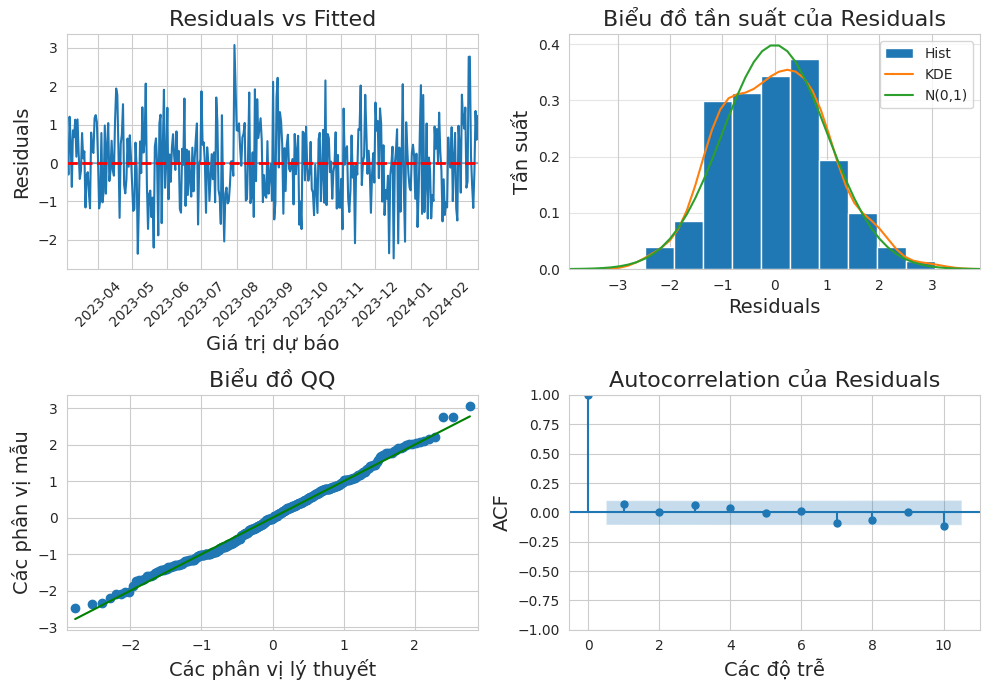

In [75]:
# Lấy các biểu đồ chẩn đoán
fig = results.plot_diagnostics(figsize=(10, 7))

# Tùy chỉnh biểu đồ đầu tiên (Residuals vs. Fitted)
ax1 = fig.axes[0]
ax1.set_title('Residuals vs Fitted', fontsize=16)
ax1.set_xlabel('Giá trị dự báo', fontsize=14)
ax1.set_ylabel('Residuals', fontsize=14)
ax1.axhline(0, color='red', linestyle='--', linewidth=2)

# Xoay nhãn trục x
for label in ax1.get_xticklabels():
    label.set_rotation(45)  # Xoay nhãn trục x 45 độ

# Tùy chỉnh biểu đồ thứ hai (Histogram of Residuals)
ax2 = fig.axes[1]
ax2.set_title('Biểu đồ tần suất của Residuals', fontsize=16)
ax2.set_xlabel('Residuals', fontsize=14)
ax2.set_ylabel('Tần suất', fontsize=14)
ax2.grid(axis='y', alpha=0.5)

# Tùy chỉnh biểu đồ thứ ba (QQ-Plot)
ax3 = fig.axes[2]
ax3.set_title('Biểu đồ QQ', fontsize=16)
ax3.set_xlabel('Các phân vị lý thuyết', fontsize=14)
ax3.set_ylabel('Các phân vị mẫu', fontsize=14)
ax3.get_lines()[1].set_color('green')  # Thay đổi màu của đường 45 độ

# Tùy chỉnh biểu đồ thứ tư (Autocorrelation của Residuals)
ax4 = fig.axes[3]
ax4.set_title('Autocorrelation của Residuals', fontsize=16)
ax4.set_xlabel('Các độ trễ', fontsize=14)
ax4.set_ylabel('ACF', fontsize=14)

plt.tight_layout()
plt.show()


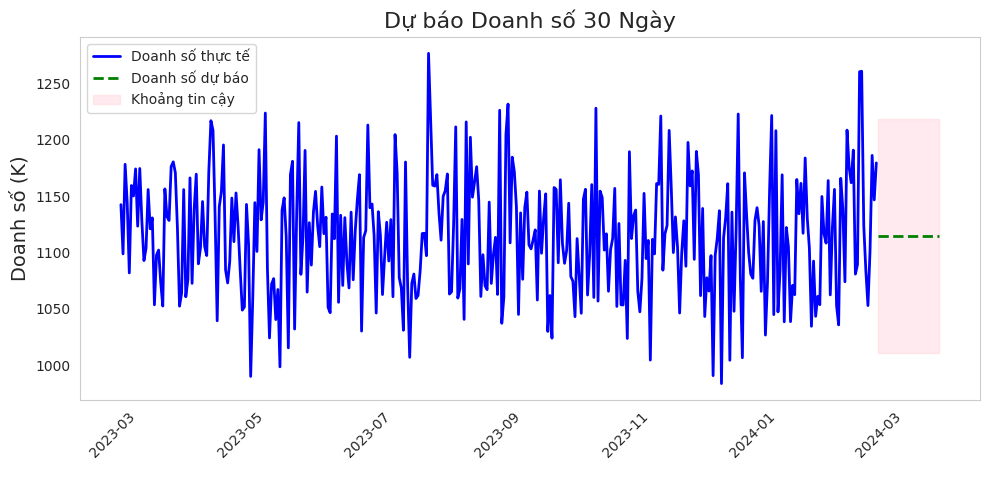

In [78]:
# Dự báo trong 30 ngày tới
daily_sale_df.reset_index(inplace=True)  # Reset lại chỉ mục nếu cần
n_periods = 30  # Số ngày dự báo
forecast, conf_int = results.predict(n_periods=n_periods, return_conf_int=True)  # Dự báo và khoảng tin cậy

# Tạo phạm vi ngày cho các ngày dự báo
forecast_index = pd.date_range(start=daily_sale_df['Date'].iloc[-1] + pd.Timedelta(days=1), periods=n_periods)

# Tạo DataFrame cho kết quả dự báo
forecast_df = pd.DataFrame(forecast, columns=['Forecasted Amount'])
forecast_df.set_index(forecast_index, inplace=True)

# Đảm bảo khoảng tin cậy là một DataFrame để vẽ
conf_int_df = pd.DataFrame(conf_int, index=forecast_index, columns=['Lower CI', 'Upper CI'])

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

# Vẽ doanh số thực tế
plt.plot(daily_sale_df['Date'], daily_sale_df['Total_Amount'], label='Doanh số thực tế', color='blue', linewidth=2)

# Vẽ doanh số dự báo
plt.plot(forecast_df.index, forecast_df['Forecasted Amount'], label='Doanh số dự báo', color='green', linestyle='--', linewidth=2)

# Điền giữa khoảng tin cậy
plt.fill_between(conf_int_df.index,
                 conf_int_df['Lower CI'],
                 conf_int_df['Upper CI'], color='pink', alpha=0.3, label='Khoảng tin cậy')

# Thêm tiêu đề và nhãn cho các trục
plt.title('Dự báo Doanh số 30 Ngày', fontsize=16)
plt.xlabel(' ')
plt.ylabel('Doanh số (K)', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()